<h1> <b> Configuraciones y rutas

In [1]:
# Librerías
import sys
import torch
import numpy as np
import random
import copy
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn

# Importes
from modelo     import crear_modelo
from agregacion import agregar_pesos
from tqdm import tqdm
from pathlib import Path
sys.path.append(str(Path(".").resolve()))
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import random_split
from sklearn.metrics import (roc_auc_score, confusion_matrix, f1_score, recall_score, precision_score)

# Semilla
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

# Dispositivo
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

Dispositivo: cuda


In [2]:
# Rutas por centro
BASE_DIR = Path("..")

CENTROS = {
    "center_1": {
        "train": BASE_DIR / "preprocesamiento/output/center_1/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_1/preprocesamiento_test",
    },
    "center_2": {
        "train": BASE_DIR / "preprocesamiento/output/center_2/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_2/preprocesamiento_test",
    },
    "center_3": {
        "train": BASE_DIR / "preprocesamiento/output/center_3/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_3/preprocesamiento_test",
    },
    "center_4": {
        "train": BASE_DIR / "preprocesamiento/output/center_4/preprocesamiento_train",
        "test" : BASE_DIR / "preprocesamiento/output/center_4/preprocesamiento_test",
    },
}

# Hiperparámetros
BATCH_SIZE       = 16
EPOCHS_LOCAL     = 20     # épocas que entrena cada centro por ronda
RONDAS           = 30    # rondas de comunicación federada
LR               = 1e-4
PACIENCIA        = 10     # early stopping

# Directorio de pesos
PESOS_DIR = Path("pesos")
PESOS_DIR.mkdir(exist_ok=True)

# Verificar que los centros existen
for nombre, rutas in CENTROS.items():
    train_ok = rutas["train"].exists()
    test_ok  = rutas["test"].exists()
    print(f"  {nombre} — train: {'Ok' if train_ok else 'Bad'} | test: {'Ok' if test_ok else 'Bad'}")

  center_1 — train: Ok | test: Ok
  center_2 — train: Ok | test: Ok
  center_3 — train: Ok | test: Ok
  center_4 — train: Ok | test: Ok


<h1><b> Dataset y dataloader

In [3]:
# Dataset y DataLoader personalizados para nuestros archivos .npy
class StrokeDataset(Dataset):

    def __init__(self, archivos):
        # Guardamos las rutas de los archivos .npy
        self.archivos = archivos

    def __len__(self):
        # El número de muestras es el número de archivos .npy
        return len(self.archivos)

    def __getitem__(self, idx):
        # Cargar imagen
        ruta   = self.archivos[idx]
        imagen = np.load(ruta).astype(np.float32)
        imagen = torch.from_numpy(imagen)

        nombre = ruta.stem
        # contiene "STROKE" para positivos y no lo contiene para negativos
        label  = 1 if "STROKE" in nombre else 0

        # Retorno como tensor de PyTorch del label (0 o 1) y la imagen
        return imagen, torch.tensor(label, dtype=torch.float32)

# Función para cargar los datos de un centro
def cargar_centro(rutas_centro):

    # Listar y ordenar los archivos .npy en train y test
    archivos_train = sorted(rutas_centro["train"].glob("*.npy"))
    archivos_test  = sorted(rutas_centro["test"].glob("*.npy"))

    # Crear datasets
    dataset_train = StrokeDataset(archivos_train)
    dataset_test  = StrokeDataset(archivos_test)

    # Crear dataloaders
    loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
    loader_test  = DataLoader(dataset_test,  batch_size=BATCH_SIZE, shuffle=False)

    # Retornar los datasets y dataloaders
    return {
        "dataset_train": dataset_train,
        "dataset_test" : dataset_test,
        "loader_train" : loader_train,
        "loader_test"  : loader_test,
    }

# Cargar datos de todos los centros
datos_centros = {}

for nombre, rutas in CENTROS.items():
    datos_centros[nombre] = cargar_centro(rutas)


# Verificación
print(f"{'Centro':<12} {'Train':>8} {'Test':>8}")
print("-" * 30)
for nombre, datos in datos_centros.items():
    n_train = len(datos["dataset_train"])
    n_test  = len(datos["dataset_test"])
    print(f"{nombre:<12} {n_train:>8} {n_test:>8}")

Centro          Train     Test
------------------------------
center_1         3040      760
center_2          960      240
center_3          679      171
center_4         1280      320


In [4]:
# Train divido en: 80% para entrenamiento y 20% para validación dentro de cada centro
def split_train_val(dataset, seed=SEED):
    val_size   = int(len(dataset) * 0.2)
    train_size = len(dataset) - val_size
    return random_split(dataset, [train_size, val_size],
                        generator=torch.Generator().manual_seed(seed))


# Crear loaders con split para cada centro
for nombre, datos in datos_centros.items():
    train_split, val_split = split_train_val(datos["dataset_train"])

    datos["loader_train"] = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True)
    datos["loader_val"]   = DataLoader(val_split,   batch_size=BATCH_SIZE, shuffle=False)
    datos["n_train"]      = len(train_split)
    datos["n_val"]        = len(val_split)

print(f"{'Centro':<12} {'Train':>8} {'Val':>8}")
print("-" * 30)
for nombre, datos in datos_centros.items():
    print(f"{nombre:<12} {datos['n_train']:>8} {datos['n_val']:>8}")

Centro          Train      Val
------------------------------
center_1         2432      608
center_2          768      192
center_3          544      135
center_4         1024      256


<h1><b> Modelo global

In [5]:
# Modelo global
modelo_global = crear_modelo().to(DEVICE)

# Ruta donde guardar el mejor modelo global
MEJOR_MODELO_PATH = PESOS_DIR / "modelo_global_mejor.pth"

total_params = sum(p.numel() for p in modelo_global.parameters())
print(f"Parámetros : {total_params:,}")
print(f"Dispositivo: {DEVICE}")

Parámetros : 11,173,889
Dispositivo: cuda


<h1><b> Entrenamiento local por centro

In [6]:
# Funciones de pérdida por centro
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        bce   = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt    = torch.where(targets == 1, probs, 1 - probs)
        loss  = ((1 - pt) ** self.gamma) * bce
        return loss.mean()

In [7]:
LOSS_POR_CENTRO = {
    "center_1": nn.BCEWithLogitsLoss(),
    "center_2": nn.BCEWithLogitsLoss(),
    "center_3": FocalLoss(gamma=2.0),
    "center_4": nn.BCEWithLogitsLoss(pos_weight=torch.tensor([588/692]).to(DEVICE)),
}

In [8]:
def entrenar_centro(nombre, modelo_global, loader_train, loader_val, epochs):
    """
    Entrena localmente y retorna los mejores pesos
    y el val_loss correspondiente.
    """
    # Copia local del modelo global — no modificamos el global
    modelo_local = copy.deepcopy(modelo_global)
    criterio     = LOSS_POR_CENTRO[nombre] # es mejor para clasificación binaria con logits

    # Optimizador para el modelo local
    optimizer    = torch.optim.AdamW(modelo_local.parameters(), lr=LR)

    # Variables para guardar la mejor época local
    mejor_val_loss   = float("inf")
    mejores_pesos    = None
    mejor_val_acc  = 0.0

    for epoca in range(epochs):
        # Train
        modelo_local.train()

        # Variables para acumular métricas
        train_loss, train_correctos = 0.0, 0

        for imagenes, labels in loader_train:
            imagenes = imagenes.to(DEVICE)
            # (batch_size, 1) para BCEWithLogitsLoss
            labels   = labels.to(DEVICE).unsqueeze(1)

            # zero_grad es importante para no acumular gradientes entre lotes
            optimizer.zero_grad()
            # forward + backward
            salida = modelo_local(imagenes)
            loss   = criterio(salida, labels)
            loss.backward()
            # actualizar pesos locales
            optimizer.step()

            # Acumular métricas para esta época
            train_loss      += loss.item()
            preds            = (torch.sigmoid(salida) >= 0.5).float()
            train_correctos += (preds == labels).sum().item()

        # Val
        modelo_local.eval()
        val_loss, val_correctos = 0.0, 0

        # No necesitamos gradientes para la validación
        with torch.no_grad():
            for imagenes, labels in loader_val:
                imagenes = imagenes.to(DEVICE)
                labels   = labels.to(DEVICE).unsqueeze(1)
                salida   = modelo_local(imagenes)
                loss     = criterio(salida, labels)

                val_loss      += loss.item()
                preds          = (torch.sigmoid(salida) >= 0.5).float()
                val_correctos += (preds == labels).sum().item()
        
        # Promedio de métricas por época
        train_loss /= len(loader_train)
        val_loss   /= len(loader_val)
        train_acc   = train_correctos / len(loader_train.dataset)
        val_acc     = val_correctos   / len(loader_val.dataset)

        print(f"      [{nombre}] época {epoca+1:02d}/{epochs} — "
              f"train_loss: {train_loss:.4f} acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f} acc: {val_acc:.4f}")
        
        
        # Guardar mejor época local
        if val_loss < mejor_val_loss:
            mejor_val_loss = val_loss
            mejor_val_acc  = val_acc
            mejores_pesos  = copy.deepcopy(modelo_local.state_dict())
        

    # return mejores_pesos, mejor_val_loss
    return mejores_pesos, mejor_val_loss, mejor_val_acc

# **Entrenamiento Federado (FedAvg)**

In [9]:
# Rondas federadas

# Variables para seguimiento de la mejor ronda global
mejor_val_global   = float("inf")
rondas_sin_mejora  = 0
total_muestras     = sum(d["n_train"] for d in datos_centros.values())

historial = {"ronda": [], "val_loss": []}

# Entrenamiento federado
for ronda in range(1, RONDAS + 1):

    print(f"\n{'='*60}")
    print(f"  RONDA {ronda}/{RONDAS}")
    print(f"{'='*60}")

    pesos_centros    = []
    val_losses       = []
    val_accs         = []
    muestras_centros = []


    # Entrenamiento local por centro
    for nombre, datos in datos_centros.items():
        print(f"\n  Centro: {nombre}")
        pesos, val_loss, val_acc = entrenar_centro(
            nombre,
            modelo_global,
            datos["loader_train"],
            datos["loader_val"],
            EPOCHS_LOCAL
        )
        pesos_centros.append(pesos)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        muestras_centros.append(datos["n_train"])

    # FedAvg
    pesos_globales = agregar_pesos(pesos_centros, muestras_centros)
    modelo_global.load_state_dict(pesos_globales)

    # Val global ponderada
    val_global = sum(
        (1 - va) * (n / total_muestras)
        for va, n in zip(val_accs, muestras_centros)
    )


    historial["ronda"].append(ronda)
    historial["val_loss"].append(val_global)

    print(f"\n  {'─'*55}")
    print(f"  Ronda {ronda} — val_loss global: {val_global:.4f}")


    # Guardar mejor modelo global
    if val_global < mejor_val_global:

        mejor_val_global  = val_global
        rondas_sin_mejora = 0
        torch.save(modelo_global.state_dict(), MEJOR_MODELO_PATH)
        print(f"  Mejor modelo global guardado (val_loss: {mejor_val_global:.4f})")

    else:
        
        rondas_sin_mejora += 1
        print(f"  Sin mejora {rondas_sin_mejora}/{PACIENCIA}")

    # Early stopping
    if rondas_sin_mejora >= PACIENCIA:
        print(f"\n  Early stopping en ronda {ronda}")
        break


print(f"\n{'='*60}")
print(f"Entrenamiento federado finalizado")
print(f"Mejor val_loss global: {mejor_val_global:.4f}")
print(f"Modelo guardado en   : {MEJOR_MODELO_PATH}")


  RONDA 1/30

  Centro: center_1
      [center_1] época 01/20 — train_loss: 0.2453 acc: 0.8882 | val_loss: 0.0679 acc: 0.9753
      [center_1] época 02/20 — train_loss: 0.0460 acc: 0.9856 | val_loss: 0.0749 acc: 0.9720
      [center_1] época 03/20 — train_loss: 0.0212 acc: 0.9942 | val_loss: 0.0607 acc: 0.9819
      [center_1] época 04/20 — train_loss: 0.0344 acc: 0.9889 | val_loss: 0.0311 acc: 0.9885
      [center_1] época 05/20 — train_loss: 0.0186 acc: 0.9947 | val_loss: 0.0316 acc: 0.9918
      [center_1] época 06/20 — train_loss: 0.0130 acc: 0.9967 | val_loss: 0.0254 acc: 0.9934
      [center_1] época 07/20 — train_loss: 0.0074 acc: 0.9979 | val_loss: 0.0175 acc: 0.9967
      [center_1] época 08/20 — train_loss: 0.0120 acc: 0.9963 | val_loss: 0.0159 acc: 0.9951
      [center_1] época 09/20 — train_loss: 0.0157 acc: 0.9951 | val_loss: 0.0636 acc: 0.9819
      [center_1] época 10/20 — train_loss: 0.0180 acc: 0.9959 | val_loss: 0.0380 acc: 0.9885
      [center_1] época 11/20 — train

<h2><b> Evaluación

In [10]:
# Cargar el mejor modelo global para evaluación final
modelo_global.load_state_dict(torch.load(MEJOR_MODELO_PATH, map_location=DEVICE))
modelo_global.eval()

# Evaluación final en cada centro
def evaluar_centro(nombre, modelo, loader_test):
    todos_labels = []
    todos_probs  = []
    todos_preds  = []

    with torch.no_grad():
        for imagenes, labels in loader_test:
            imagenes = imagenes.to(DEVICE)
            salida   = modelo(imagenes)
            probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
            preds    = (probs >= 0.5).astype(int)

            todos_labels.extend(labels.numpy().astype(int))
            todos_probs.extend(probs)
            todos_preds.extend(preds)

    auc          = roc_auc_score(todos_labels, todos_probs)
    f1           = f1_score(todos_labels, todos_preds)
    sensibilidad  = recall_score(todos_labels, todos_preds)
    especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
    precision    = precision_score(todos_labels, todos_preds)
    accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)
    cm           = confusion_matrix(todos_labels, todos_preds)

    return {
        "auc"         : auc,
        "f1"          : f1,
        "sensibilidad": sensibilidad,
        "especificidad": especificidad,
        "precision"   : precision,
        "accuracy"    : accuracy,
        "cm"          : cm,
        "labels"      : todos_labels,
        "preds"       : todos_preds,
    }


# Evaluar en cada centro
resultados = {}

for nombre, datos in datos_centros.items():
    resultados[nombre] = evaluar_centro(nombre, modelo_global, datos["loader_test"])

# Metricas por centro
print(f"\n{'='*65}")
print(f"  EVALUACIÓN FINAL — TEST SET POR CENTRO")
print(f"{'='*65}")
print(f"{'Métrica':<18} {'Center 1':>10} {'Center 2':>10} {'Center 3':>10} {'Center 4':>10}")
print(f"{'─'*65}")

metricas = ["auc", "accuracy", "f1", "sensibilidad", "especificidad", "precision"]
nombres  = ["AUC-ROC", "Accuracy", "F1-Score", "Sensibilidad", "Especificidad", "Precisión"]

for metrica, nombre_m in zip(metricas, nombres):
    vals = [resultados[c][metrica] for c in datos_centros]
    print(f"  {nombre_m:<16} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f} {vals[3]:>10.4f}")

print(f"{'='*65}")


  EVALUACIÓN FINAL — TEST SET POR CENTRO
Métrica              Center 1   Center 2   Center 3   Center 4
─────────────────────────────────────────────────────────────────
  AUC-ROC              0.9510     0.9240     0.1795     0.3550
  Accuracy             0.8855     0.7875     0.2749     0.4688
  F1-Score             0.8793     0.8401     0.4312     0.6272
  Sensibilidad         0.8342     0.9571     0.4393     0.8266
  Especificidad        0.9368     0.5500     0.0000     0.0476
  Precisión            0.9296     0.7486     0.4234     0.5053


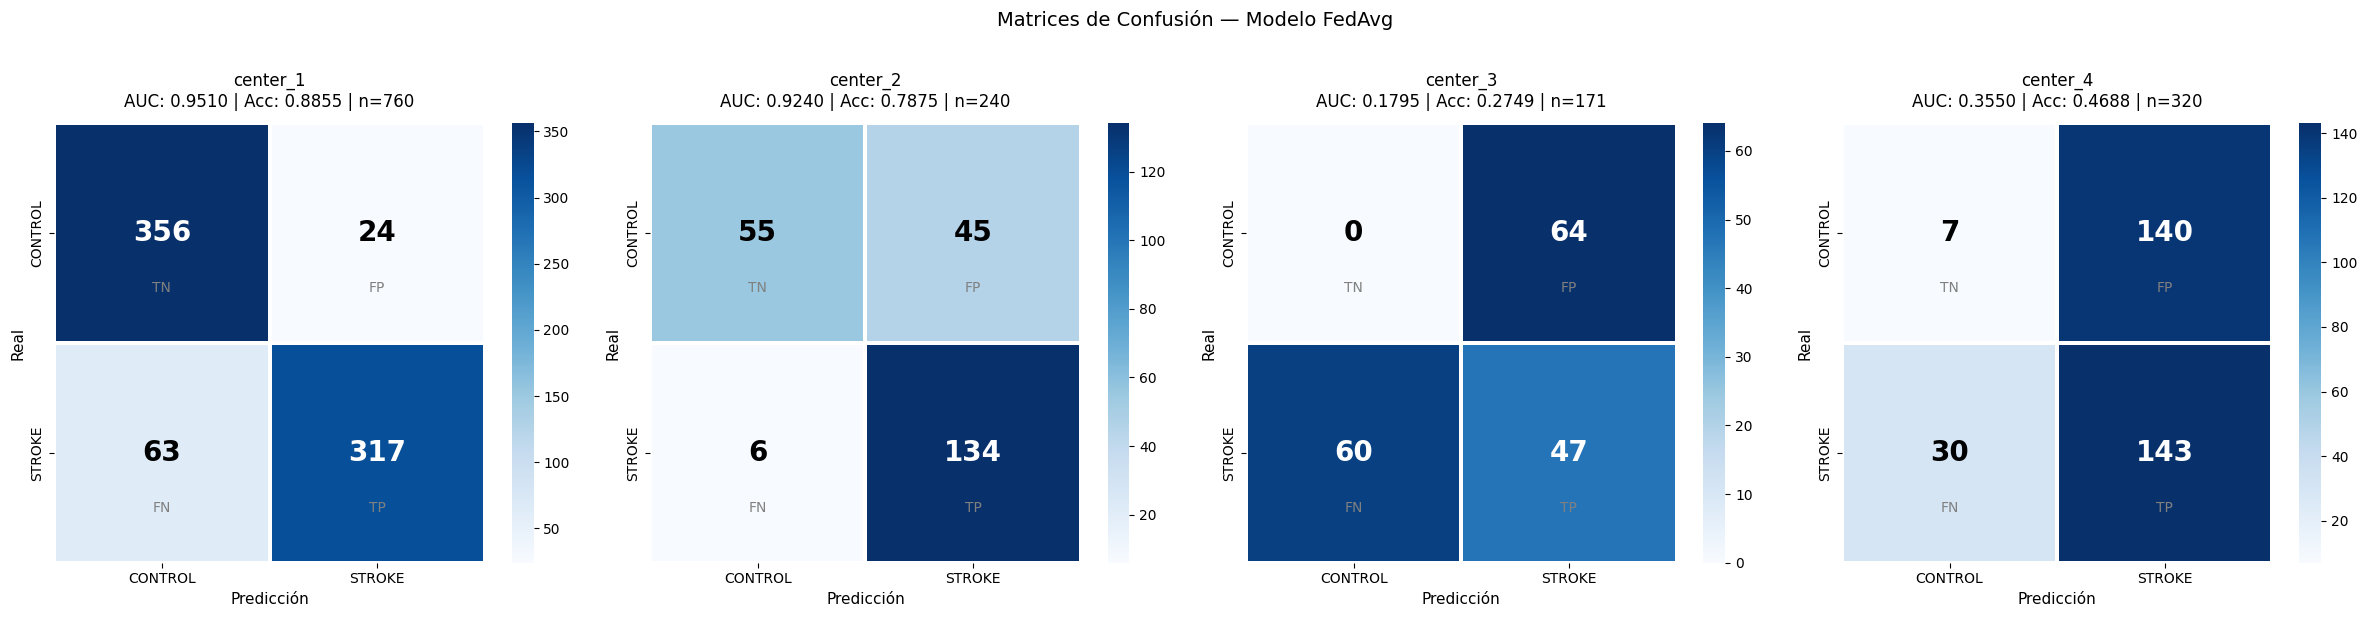

In [13]:
# Matriz de confusión por centro
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = res["cm"]

    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=["CONTROL", "STROKE"],
                yticklabels=["CONTROL", "STROKE"],
                linewidths=1.5, linecolor="white", ax=ax)

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                    ha="center", va="center",
                    fontsize=20, fontweight="bold", color=color)

    etiquetas = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                    ha="center", va="center",
                    fontsize=10, color="gray")

    n_test   = len(res["labels"])
    accuracy = res["accuracy"]
    ax.set_title(f"{nombre}\nAUC: {res['auc']:.4f} | Acc: {accuracy:.4f} | n={n_test}",
                 fontsize=12, pad=12)
    ax.set_xlabel("Predicción", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)

plt.suptitle("Matrices de Confusión — Modelo FedAvg", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# **Entrenamiento Federado (FedProx)**

<h3><b> Entrenamiento local por centro (con FedProx)

In [19]:
# Modelo global
modelo_global = crear_modelo().to(DEVICE)

# Ruta donde guardar el mejor modelo global
MEJOR_MODELO_PATH = PESOS_DIR / "modelo_global_fedprox_mejor.pth"

total_params = sum(p.numel() for p in modelo_global.parameters())
print(f"Parámetros : {total_params:,}")
print(f"Dispositivo: {DEVICE}")

Parámetros : 11,173,889
Dispositivo: cuda


In [20]:
def entrenar_centro(nombre, modelo_global, loader_train, loader_val, epochs, mu=0.01):
    
    modelo_local = copy.deepcopy(modelo_global)
    criterio     = LOSS_POR_CENTRO[nombre]
    optimizer    = torch.optim.AdamW(modelo_local.parameters(), lr=LR)

    # Guardamos los pesos del modelo global como referencia (el punto de anclaje)
    pesos_ref = {k: v.clone().detach() for k, v in modelo_global.state_dict().items()}

    mejor_val_loss = float("inf")
    mejores_pesos  = None
    mejor_val_acc  = 0.0

    for epoca in range(epochs):
        modelo_local.train()
        train_loss, train_correctos = 0.0, 0

        for imagenes, labels in loader_train:
            imagenes = imagenes.to(DEVICE)
            labels   = labels.to(DEVICE).unsqueeze(1)
            optimizer.zero_grad()

            salida = modelo_local(imagenes)

            # Loss normal
            loss_normal = criterio(salida, labels)

            # Castigo proximal — distancia entre pesos locales y globales
            castigo = 0.0
            for k, param in modelo_local.named_parameters():
                if k in pesos_ref:
                    castigo += ((param - pesos_ref[k]) ** 2).sum()
            castigo = (mu / 2) * castigo

            # Loss total = loss normal + castigo
            loss_total = loss_normal + castigo

            loss_total.backward()
            optimizer.step()

            train_loss      += loss_normal.item()  # solo monitoreamos loss normal
            preds            = (torch.sigmoid(salida) >= 0.5).float()
            train_correctos += (preds == labels).sum().item()

        # Val
        modelo_local.eval()
        val_loss, val_correctos = 0.0, 0

        with torch.no_grad():
            for imagenes, labels in loader_val:
                imagenes = imagenes.to(DEVICE)
                labels   = labels.to(DEVICE).unsqueeze(1)
                salida   = modelo_local(imagenes)
                loss     = criterio(salida, labels)
                val_loss      += loss.item()
                preds          = (torch.sigmoid(salida) >= 0.5).float()
                val_correctos += (preds == labels).sum().item()

        train_loss /= len(loader_train)
        val_loss   /= len(loader_val)
        train_acc   = train_correctos / len(loader_train.dataset)
        val_acc     = val_correctos   / len(loader_val.dataset)

        print(f"      [{nombre}] época {epoca+1:02d}/{epochs} — "
              f"train_loss: {train_loss:.4f} acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f} acc: {val_acc:.4f}")

        if val_loss < mejor_val_loss:
            mejor_val_loss = val_loss
            mejor_val_acc  = val_acc
            mejores_pesos  = copy.deepcopy(modelo_local.state_dict())
            print(f"        → mejor época local: {epoca+1} | val_loss: {mejor_val_loss:.4f} | val_acc: {mejor_val_acc:.4f}")

    return mejores_pesos, mejor_val_loss, mejor_val_acc

In [21]:
# Rondas federadas

# Variables para seguimiento de la mejor ronda global
mejor_val_global   = float("inf")
rondas_sin_mejora  = 0
total_muestras     = sum(d["n_train"] for d in datos_centros.values())

historial = {"ronda": [], "val_loss": []}

# Entrenamiento federado
for ronda in range(1, RONDAS + 1):

    print(f"\n{'='*60}")
    print(f"  RONDA {ronda}/{RONDAS}")
    print(f"{'='*60}")

    pesos_centros    = []
    val_losses       = []
    val_accs         = []
    muestras_centros = []


    # Entrenamiento local por centro
    for nombre, datos in datos_centros.items():
        print(f"\n  Centro: {nombre}")
        pesos, val_loss, val_acc = entrenar_centro(
            nombre,
            modelo_global,
            datos["loader_train"],
            datos["loader_val"],
            EPOCHS_LOCAL
        )
        pesos_centros.append(pesos)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        muestras_centros.append(datos["n_train"])

    # FedAvg
    pesos_globales = agregar_pesos(pesos_centros, muestras_centros)
    modelo_global.load_state_dict(pesos_globales)

    # Val global ponderada
    val_global = sum(
        (1 - va) * (n / total_muestras)
        for va, n in zip(val_accs, muestras_centros)
    )


    historial["ronda"].append(ronda)
    historial["val_loss"].append(val_global)

    print(f"\n  {'─'*55}")
    print(f"  Ronda {ronda} — val_loss global: {val_global:.4f}")


    # Guardar mejor modelo global
    if val_global < mejor_val_global:

        mejor_val_global  = val_global
        rondas_sin_mejora = 0
        torch.save(modelo_global.state_dict(), MEJOR_MODELO_PATH)
        print(f"  Mejor modelo global guardado (val_loss: {mejor_val_global:.4f})")

    else:
        
        rondas_sin_mejora += 1
        print(f"  Sin mejora {rondas_sin_mejora}/{PACIENCIA}")

    # Early stopping
    if rondas_sin_mejora >= PACIENCIA:
        print(f"\n  Early stopping en ronda {ronda}")
        break


print(f"\n{'='*60}")
print(f"Entrenamiento federado finalizado")
print(f"Mejor val_loss global: {mejor_val_global:.4f}")
print(f"Modelo guardado en   : {MEJOR_MODELO_PATH}")


  RONDA 1/30

  Centro: center_1
      [center_1] época 01/20 — train_loss: 0.2563 acc: 0.8914 | val_loss: 1.0250 acc: 0.6086
        → mejor época local: 1 | val_loss: 1.0250 | val_acc: 0.6086
      [center_1] época 02/20 — train_loss: 0.0503 acc: 0.9827 | val_loss: 0.0551 acc: 0.9786
        → mejor época local: 2 | val_loss: 0.0551 | val_acc: 0.9786
      [center_1] época 03/20 — train_loss: 0.0274 acc: 0.9914 | val_loss: 0.0721 acc: 0.9803
      [center_1] época 04/20 — train_loss: 0.0255 acc: 0.9926 | val_loss: 0.0502 acc: 0.9803
        → mejor época local: 4 | val_loss: 0.0502 | val_acc: 0.9803
      [center_1] época 05/20 — train_loss: 0.0236 acc: 0.9930 | val_loss: 0.0656 acc: 0.9737
      [center_1] época 06/20 — train_loss: 0.0287 acc: 0.9918 | val_loss: 0.0488 acc: 0.9868
        → mejor época local: 6 | val_loss: 0.0488 | val_acc: 0.9868
      [center_1] época 07/20 — train_loss: 0.0419 acc: 0.9827 | val_loss: 0.0734 acc: 0.9770
      [center_1] época 08/20 — train_loss: 

<h3><b> Evaluación

In [22]:
MEJOR_MODELO_PATH = PESOS_DIR / "modelo_global_fedprox_mejor.pth"

In [23]:
# Cargar el mejor modelo global para evaluación final
modelo_global.load_state_dict(torch.load(MEJOR_MODELO_PATH, map_location=DEVICE))
modelo_global.eval()

# Evaluación final en cada centro
def evaluar_centro(nombre, modelo, loader_test):
    todos_labels = []
    todos_probs  = []
    todos_preds  = []

    with torch.no_grad():
        for imagenes, labels in loader_test:
            imagenes = imagenes.to(DEVICE)
            salida   = modelo(imagenes)
            probs    = torch.sigmoid(salida).squeeze(1).cpu().numpy()
            preds    = (probs >= 0.5).astype(int)

            todos_labels.extend(labels.numpy().astype(int))
            todos_probs.extend(probs)
            todos_preds.extend(preds)

    auc          = roc_auc_score(todos_labels, todos_probs)
    f1           = f1_score(todos_labels, todos_preds)
    sensibilidad  = recall_score(todos_labels, todos_preds)
    especificidad = recall_score(todos_labels, todos_preds, pos_label=0)
    precision    = precision_score(todos_labels, todos_preds)
    accuracy     = sum(p == l for p, l in zip(todos_preds, todos_labels)) / len(todos_labels)
    cm           = confusion_matrix(todos_labels, todos_preds)

    return {
        "auc"         : auc,
        "f1"          : f1,
        "sensibilidad": sensibilidad,
        "especificidad": especificidad,
        "precision"   : precision,
        "accuracy"    : accuracy,
        "cm"          : cm,
        "labels"      : todos_labels,
        "preds"       : todos_preds,
    }


# Evaluar en cada centro
resultados = {}

for nombre, datos in datos_centros.items():
    resultados[nombre] = evaluar_centro(nombre, modelo_global, datos["loader_test"])

# Metricas por centro
print(f"\n{'='*65}")
print(f"  EVALUACIÓN FINAL — TEST SET POR CENTRO")
print(f"{'='*65}")
print(f"{'Métrica':<18} {'Center 1':>10} {'Center 2':>10} {'Center 3':>10} {'Center 4':>10}")
print(f"{'─'*65}")

metricas = ["auc", "accuracy", "f1", "sensibilidad", "especificidad", "precision"]
nombres  = ["AUC-ROC", "Accuracy", "F1-Score", "Sensibilidad", "Especificidad", "Precisión"]

for metrica, nombre_m in zip(metricas, nombres):
    vals = [resultados[c][metrica] for c in datos_centros]
    print(f"  {nombre_m:<16} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f} {vals[3]:>10.4f}")

print(f"{'='*65}")


  EVALUACIÓN FINAL — TEST SET POR CENTRO
Métrica              Center 1   Center 2   Center 3   Center 4
─────────────────────────────────────────────────────────────────
  AUC-ROC              0.9670     0.9824     0.1522     0.2981
  Accuracy             0.9184     0.9625     0.2398     0.3563
  F1-Score             0.9155     0.9668     0.3810     0.5024
  Sensibilidad         0.8842     0.9357     0.3738     0.6012
  Especificidad        0.9526     1.0000     0.0156     0.0680
  Precisión            0.9492     1.0000     0.3883     0.4315


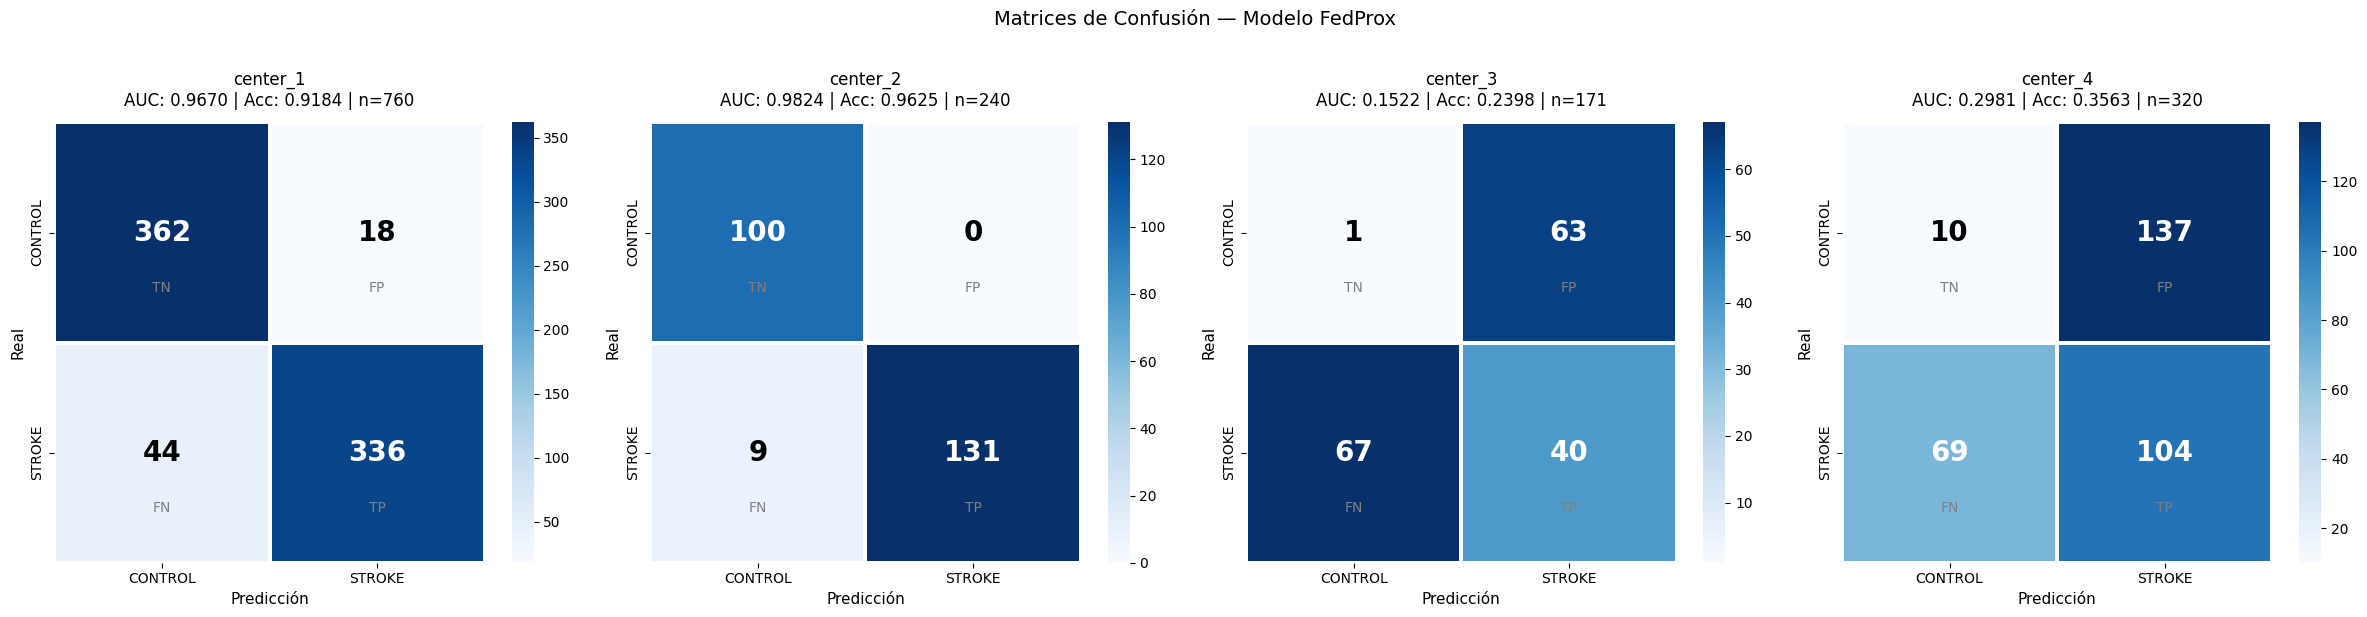

In [24]:
# Matriz de confusión por centro
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = res["cm"]

    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=["CONTROL", "STROKE"],
                yticklabels=["CONTROL", "STROKE"],
                linewidths=1.5, linecolor="white", ax=ax)

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() / 2 else "black"
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                    ha="center", va="center",
                    fontsize=20, fontweight="bold", color=color)

    etiquetas = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.75, etiquetas[i][j],
                    ha="center", va="center",
                    fontsize=10, color="gray")

    n_test   = len(res["labels"])
    accuracy = res["accuracy"]
    ax.set_title(f"{nombre}\nAUC: {res['auc']:.4f} | Acc: {accuracy:.4f} | n={n_test}",
                 fontsize=12, pad=12)
    ax.set_xlabel("Predicción", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)

plt.suptitle("Matrices de Confusión — Modelo FedProx", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()